<a href="https://colab.research.google.com/github/jessicaromero-ctrl/Advanced-Math-for-ML/blob/main/Sesion7_Actividad5_Semillas_Reproducibilidad_Independiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 7 · Actividad 5
# Semillas, variación y reproducibilidad

**Curso:** Introducción a la Inteligencia Artificial Generativa   
**Modalidad:** laboratorio guiado en Google Colab

---

## Propósito

En esta actividad experimentarás con la **semilla aleatoria** para descubrir:

- por qué un mismo prompt puede producir imágenes diferentes;
- cómo reproducir exactamente una generación;
- qué cambia cuando se modifica únicamente la semilla;
- por qué la semilla es importante en experimentos y proyectos creativos.

> **Regla experimental:** cambiaremos únicamente la semilla.  
> El modelo, el prompt, el número de pasos, el Guidance Scale, el scheduler y el tamaño permanecerán constantes.


## La idea central es:

> **La semilla determina el punto de partida aleatorio de la generación.**

### Preguntas iniciales

- Si usamos exactamente el mismo prompt, ¿la IA debería producir siempre la misma imagen?
- ¿Qué significa “repetir” un experimento generativo?
- ¿Una semilla mejor produce una imagen mejor?




# 0. Preparación del entorno

En Google Colab selecciona:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

Después ejecuta las celdas en orden.

Este cuaderno es completamente independiente y no requiere ejecutar ninguna actividad anterior.


In [2]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "No se detectó una GPU. Selecciona: "
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
    )


Versión de PyTorch: 2.11.0+cu128
GPU disponible: True
GPU detectada: Tesla T4


# 1. Configuración del guardado

Puedes guardar los resultados:

- temporalmente en Colab;
- permanentemente en Google Drive.

Para guardar en Drive cambia `USAR_DRIVE` a `True`.


In [3]:
from pathlib import Path

USAR_DRIVE = True

if USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CARPETA_RESULTADOS = Path(
        "/content/drive/MyDrive/IA_Generativa/Sesion7/Actividad5_Semillas"
    )
else:
    CARPETA_RESULTADOS = Path("/content/Actividad5_Semillas")

CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)
print("Los resultados se guardarán en:", CARPETA_RESULTADOS)


Mounted at /content/drive
Los resultados se guardarán en: /content/drive/MyDrive/IA_Generativa/Sesion7/Actividad5_Semillas


# 2. Instalación de bibliotecas

In [4]:
!pip -q install -U diffusers transformers accelerate safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 120.9 MB/s eta 0:00:00


# 3. Carga del modelo

Usaremos Stable Diffusion 1.5 con DPM-Solver++.

> **Nota:** la semilla no cambia el conocimiento del modelo ni el prompt. Cambia el ruido inicial desde el cual comienza la generación.


In [5]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageChops, ImageStat

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
    safety_checker=None
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++"
)

pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

print("Modelo cargado correctamente.")


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Modelo cargado correctamente.


# 4. Diseño del experimento

Mantendremos constantes:

- **Prompt:** una biblioteca mágica;
- **Pasos:** 25;
- **Guidance Scale:** 7.5;
- **Tamaño:** 512 × 512 píxeles;
- **Scheduler:** DPM-Solver++.

Solo cambiaremos la semilla:

`7, 42, 123, 999 y 2026`


In [6]:
PROMPT = "A magical library with floating books, warm light, cinematic, highly detailed"

STEPS = 25
GUIDANCE = 7.5
WIDTH = 512
HEIGHT = 512

SEED_VALUES = [7, 42, 123, 999, 2026]

def generar_imagen(seed, prefijo="semilla"):
    generator = torch.Generator(device="cuda").manual_seed(seed)

    inicio = time.time()

    imagen = pipe(
        prompt=PROMPT,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

    duracion = time.time() - inicio
    imagen.save(CARPETA_RESULTADOS / f"{prefijo}_{seed}.png")

    return imagen, duracion


# 5. Predicción

Antes de ejecutar responde:

1. ¿Las cinco imágenes serán parecidas o completamente diferentes?
2. ¿Qué elementos esperas que se mantengan?
3. ¿Qué elementos podrían cambiar?
4. ¿Crees que alguna semilla será “mejor” que las demás?


# 6. Generación con semillas diferentes

Se generarán cinco imágenes usando el mismo prompt y los mismos parámetros.

> **Observar:**
> - distribución de objetos;
> - punto de vista;
> - iluminación;
> - composición;
> - detalles secundarios;
> - estilo general.


In [7]:
imagenes = []
tiempos = []

for seed in SEED_VALUES:
    print(f"Generando con semilla {seed}...")
    imagen, duracion = generar_imagen(seed)
    imagenes.append(imagen)
    tiempos.append(duracion)

print("Generación terminada.")


Generando con semilla 7...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando con semilla 42...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando con semilla 123...


...

Generando con semilla 999...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando con semilla 2026...


  0%|          | 0/25 [00:00<?, ?it/s]

Generación terminada.


# 7. Comparación visual

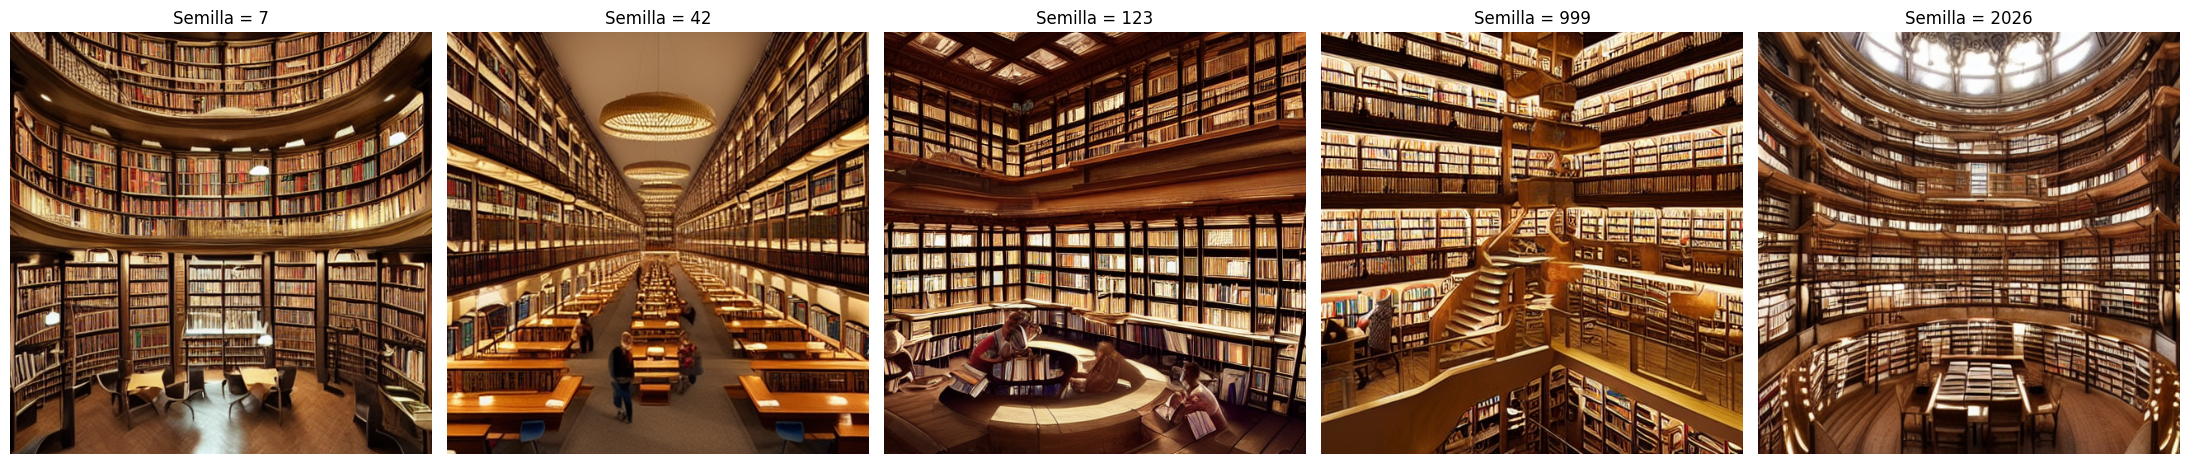

Comparación guardada en: /content/drive/MyDrive/IA_Generativa/Sesion7/Actividad5_Semillas/comparacion_semillas.png


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, imagen, seed in zip(axes, imagenes, SEED_VALUES):
    ax.imshow(imagen)
    ax.set_title(f"Semilla = {seed}")
    ax.axis("off")

plt.tight_layout()

ruta_comparacion = CARPETA_RESULTADOS / "comparacion_semillas.png"
plt.savefig(ruta_comparacion, dpi=150, bbox_inches="tight")
plt.show()

print("Comparación guardada en:", ruta_comparacion)


# 8. Registro de observaciones

Evalúa cada imagen usando una escala de 1 a 5.

| Semilla | Coherencia | Detalle | Composición | Fidelidad al prompt | Preferencia personal | Observaciones |
|---:|---:|---:|---:|---:|---:|---|
| 7 | 4.5| 4| 4| 4.5| -| No me gusta el detalle del barandal, parece hecho de asbesto.
| 42 | 4.5| 4| 4| 4.5| x| Ésta me gusta.|
| 123 | 4.5| 3| 4| 4| -| Ésta también me gusta en diseño pero no hay estructura.Hay figuras que no son personas.|
| 999 | 3| 3| 4| 3.5| -| Aquí ya está deforme.|
| 2026 | 3| 3| 4| 3| -| Aquí ya todos los elementos están deformes, ni si quiera hay en dónde sentarse a leer.|


# 9. Experimento de reproducibilidad

Ahora generaremos dos veces una imagen con la misma semilla.

Si todos los parámetros se mantienen iguales, las imágenes deberían coincidir.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

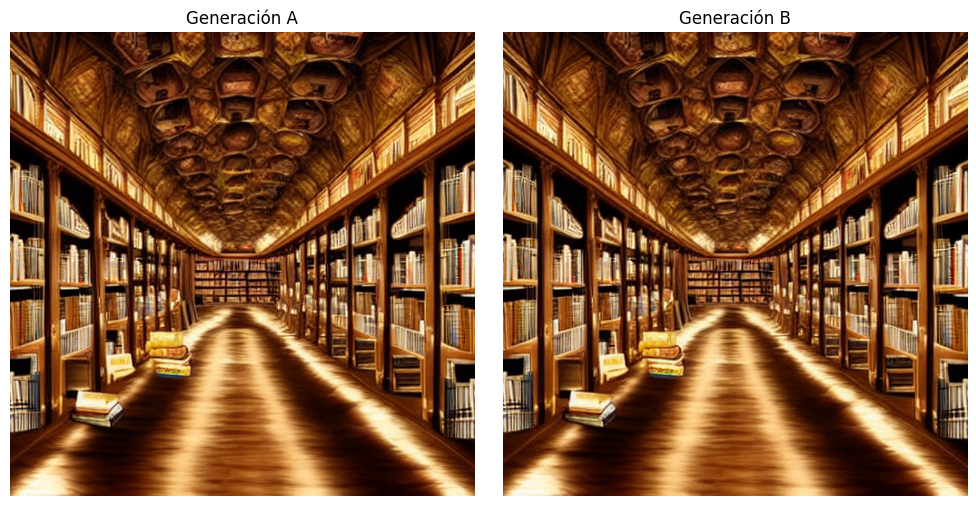

In [9]:
SEMILLA_REPETIDA = 429

imagen_a, tiempo_a = generar_imagen(SEMILLA_REPETIDA, "repeticion_A")
imagen_b, tiempo_b = generar_imagen(SEMILLA_REPETIDA, "repeticion_B")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_a)
axes[0].set_title("Generación A")
axes[0].axis("off")

axes[1].imshow(imagen_b)
axes[1].set_title("Generación B")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# 10. Verificación automática

Compararemos numéricamente las dos imágenes.

- Si la diferencia máxima es 0, las imágenes son idénticas píxel por píxel.
- Si es mayor que 0, existe alguna diferencia.


In [10]:
array_a = np.array(imagen_a).astype(np.int16)
array_b = np.array(imagen_b).astype(np.int16)

diferencia_absoluta = np.abs(array_a - array_b)

print("Diferencia máxima:", diferencia_absoluta.max())
print("Diferencia promedio:", diferencia_absoluta.mean())

if diferencia_absoluta.max() == 0:
    print("Resultado: las imágenes son idénticas píxel por píxel.")
else:
    print("Resultado: las imágenes presentan diferencias.")


Diferencia máxima: 0
Diferencia promedio: 0.0
Resultado: las imágenes son idénticas píxel por píxel.


## Pregunta de interpretación

¿Por qué fue posible reproducir la imagen?

Completa:

> La imagen pudo repetirse porque mantuvimos constantes...


# 11. Contraprueba: misma semilla, prompt modificado

Mantendremos la semilla 42, pero cambiaremos una parte del prompt.

Esto permitirá comprobar que la semilla **no fija toda la imagen**: también importa la instrucción textual.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

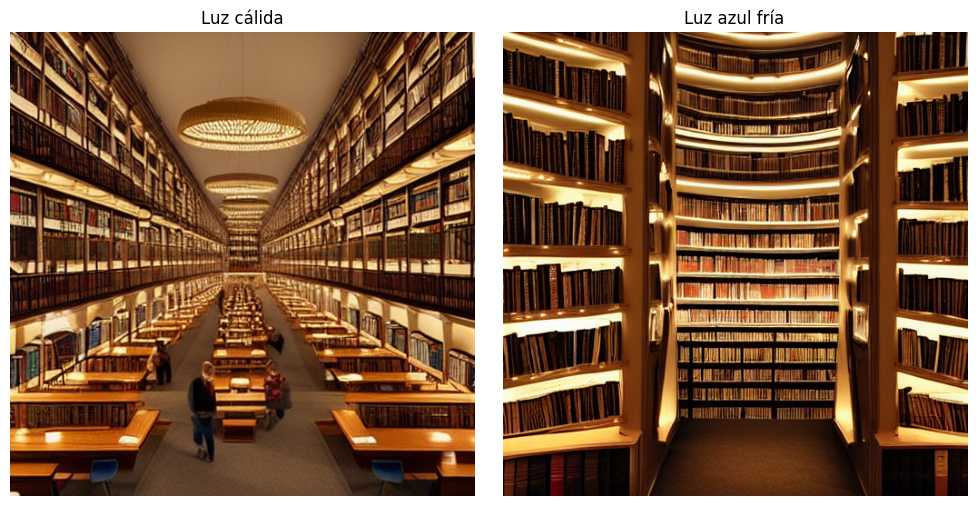

In [11]:
PROMPT_ORIGINAL = PROMPT
PROMPT_MODIFICADO = (
    "A magical library with floating books, cold blue light, "
    "cinematic, highly detailed"
)

def generar_prompt(prompt, seed):
    generator = torch.Generator(device="cuda").manual_seed(seed)

    return pipe(
        prompt=prompt,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

imagen_original = generar_prompt(PROMPT_ORIGINAL, 42)
imagen_modificada = generar_prompt(PROMPT_MODIFICADO, 42)

imagen_original.save(CARPETA_RESULTADOS / "misma_semilla_prompt_original.png")
imagen_modificada.save(CARPETA_RESULTADOS / "misma_semilla_prompt_modificado.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_original)
axes[0].set_title("Luz cálida")
axes[0].axis("off")

axes[1].imshow(imagen_modificada)
axes[1].set_title("Luz azul fría")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# 12. Preguntas de análisis

### 1.
¿Qué elementos permanecieron similares entre las distintas semillas?

### 2.
¿Qué elementos cambiaron con mayor intensidad?

### 3.
¿La semilla con mayor valor produjo una mejor imagen?

### 4.
¿Existe una relación entre el número de la semilla y la calidad?

### 5.
¿Qué demostró el experimento de repetición?

### 6.
¿Por qué cambiar el prompt modificó la imagen aun conservando la misma semilla?

### 7.
¿En qué situaciones profesionales convendría registrar la semilla?

### 8.
Formula una conclusión:

> La semilla controla...


## Reflexión:
> “La semilla no es un nivel de calidad. Es una dirección dentro del espacio de posibilidades.”


# 13. Mini reto: búsqueda de una composición

Tu objetivo es encontrar una semilla que produzca una composición interesante para este prompt:

> `A robot chef preparing dinner in a futuristic kitchen`

Prueba **tres semillas distintas**.

Después:

1. elige tu imagen favorita;
2. registra la semilla;
3. vuelve a generarla;
4. demuestra que puedes reproducirla.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

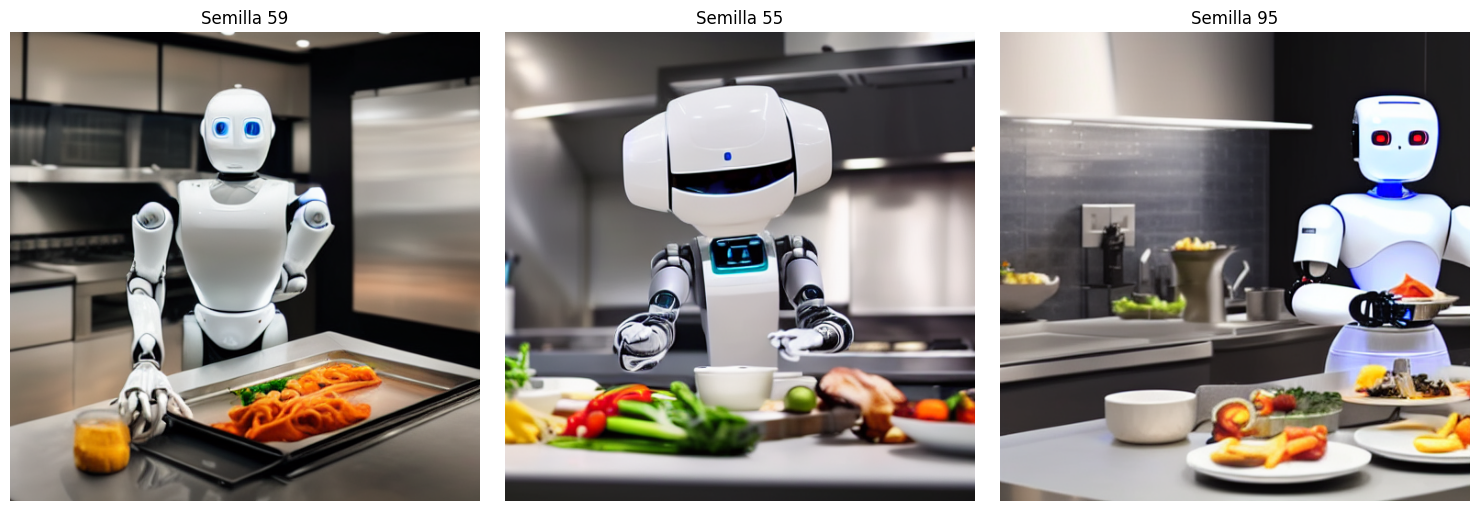

In [18]:
PROMPT_RETO = "A robot chef preparing dinner in a futuristic kitchen, cinematic, highly detailed"

SEMILLAS_RETO = [59, 55, 95]

def generar_reto(seed):
    generator = torch.Generator(device="cuda").manual_seed(seed)
    imagen = pipe(
        prompt=PROMPT_RETO,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

    imagen.save(CARPETA_RESULTADOS / f"reto_semilla_{seed}.png")
    return imagen

imagenes_reto = [generar_reto(seed) for seed in SEMILLAS_RETO]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, imagen, seed in zip(axes, imagenes_reto, SEMILLAS_RETO):
    ax.imshow(imagen)
    ax.set_title(f"Semilla {seed}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Reproducción de la imagen seleccionada

Escribe la semilla elegida y ejecuta la celda.


  0%|          | 0/25 [00:00<?, ?it/s]

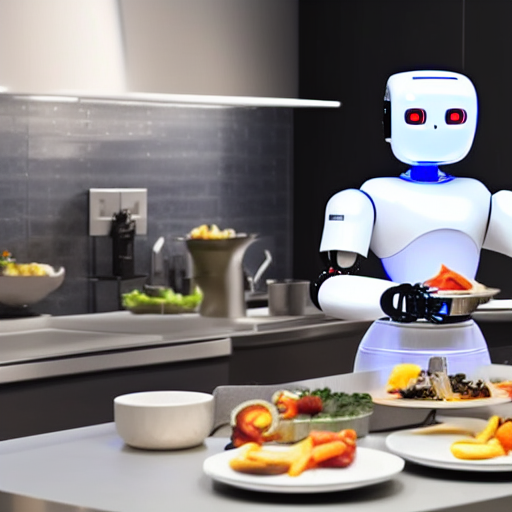

Semilla registrada: 95


In [17]:
SEMILLA_ELEGIDA = 95  # Sustituye por tu semilla favorita

imagen_reproducida = generar_reto(SEMILLA_ELEGIDA)
display(imagen_reproducida)

print("Semilla registrada:", SEMILLA_ELEGIDA)


## Reflexión del mini reto

- Semillas probadas:
- Semilla seleccionada:
- Razón de la elección:
- ¿Pudiste reproducir el resultado?
- ¿Qué ocurriría si perdieras la semilla?
- ¿Qué otro parámetro deberías registrar?


# 14. Evidencia de aprendizaje

Entrega:

1. comparación de las cinco semillas;
2. tabla de observaciones;
3. resultado de la prueba de reproducibilidad;
4. comparación con el prompt modificado;
5. imágenes del mini reto;
6. semilla seleccionada;
7. conclusión personal de máximo 100 palabras.


# 15. Cierre conceptual

La semilla determina el ruido inicial de la generación.

De forma simplificada:

- mismo prompt + distinta semilla → variaciones;
- mismo prompt + misma semilla + mismos parámetros → reproducción;
- misma semilla + prompt diferente → resultado diferente;
- una semilla mayor no implica mayor calidad.

> **La semilla permite explorar posibilidades y también repetir resultados.**
